In [174]:
# Processamento de dados
import numpy as np
import pandas as pd

# Geração de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

In [175]:
features = pd.read_csv("../data/raw/raw_features.csv", index_col=0)
metadata_cols = pd.read_csv("../data/processed/metadata_filtrada.csv").set_index("sample")[["Species", "WHO_Priority"]]

## Removendo NaN das colunas de prop_x...

In [176]:
features.head()

,densidade_genes_cromossomal_por_mb,pct_genes_cromossomal_efflux,mdr_score_cromossomal,mdr_score_plasmidial,prop_n_plasmidial_aminoglycoside,prop_n_plasmidial_beta-lactam,prop_n_plasmidial_biocide_antiseptic,prop_n_plasmidial_fluoroquinolone,prop_n_plasmidial_mls,prop_n_plasmidial_phenicol,prop_n_plasmidial_rifamycin,prop_n_plasmidial_sulfonamide_diaminopyrimidine,prop_n_plasmidial_tetracycline,pct_contigs_plasmidial,pct_plasmidial_amr,pct_plasmidial_conjugacao_amr,n_proviruses_por_mb,gc_diff_plasmid_cromossomo,virulence_score_cromossomal,virulence_score_plasmidial
sample,,,,,,,,,,,,,,,,,,,,
GCA_000216055.2,0.448222,0.000000,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.655629,0.000000,0.000000,0.896445,0.18,0,0
GCA_000316425.1,10.343931,2.127660,13,6,0.000000,1.000000,1.000000,1.0,0.000000,1.000000,1.0,0.000000,1.000000,5.675676,4.761905,0.000000,1.540586,-2.92,8,4
GCA_000223095.2,1.548495,16.666667,7,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.349206,0.000000,0.000000,0.774247,-3.05,6,1
GCA_036761135.1,2.529468,10.000000,10,5,0.000000,0.166667,0.166667,0.0,0.333333,0.000000,0.0,0.166667,0.166667,18.269231,10.526316,2.631579,0.252947,0.31,4,0
GCA_003670255.1,1.748983,14.285714,8,5,0.142857,0.428571,0.142857,0.0,0.000000,0.142857,0.0,0.142857,0.000000,22.406639,9.259259,1.851852,0.999419,0.90,4,0


In [177]:
prop_cols = [c for c in features.columns if c.startswith("prop_n_plasmidial_")]

# Preenche NaN com 0
features[prop_cols] = features[prop_cols].fillna(0)

features.head()

,densidade_genes_cromossomal_por_mb,pct_genes_cromossomal_efflux,mdr_score_cromossomal,mdr_score_plasmidial,prop_n_plasmidial_aminoglycoside,prop_n_plasmidial_beta-lactam,prop_n_plasmidial_biocide_antiseptic,prop_n_plasmidial_fluoroquinolone,prop_n_plasmidial_mls,prop_n_plasmidial_phenicol,prop_n_plasmidial_rifamycin,prop_n_plasmidial_sulfonamide_diaminopyrimidine,prop_n_plasmidial_tetracycline,pct_contigs_plasmidial,pct_plasmidial_amr,pct_plasmidial_conjugacao_amr,n_proviruses_por_mb,gc_diff_plasmid_cromossomo,virulence_score_cromossomal,virulence_score_plasmidial
sample,,,,,,,,,,,,,,,,,,,,
GCA_000216055.2,0.448222,0.000000,1,0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,1.655629,0.000000,0.000000,0.896445,0.18,0,0
GCA_000316425.1,10.343931,2.127660,13,6,0.000000,1.000000,1.000000,1.0,0.000000,1.000000,1.0,0.000000,1.000000,5.675676,4.761905,0.000000,1.540586,-2.92,8,4
GCA_000223095.2,1.548495,16.666667,7,0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,6.349206,0.000000,0.000000,0.774247,-3.05,6,1
GCA_036761135.1,2.529468,10.000000,10,5,0.000000,0.166667,0.166667,0.0,0.333333,0.000000,0.0,0.166667,0.166667,18.269231,10.526316,2.631579,0.252947,0.31,4,0
GCA_003670255.1,1.748983,14.285714,8,5,0.142857,0.428571,0.142857,0.0,0.000000,0.142857,0.0,0.142857,0.000000,22.406639,9.259259,1.851852,0.999419,0.90,4,0


## Transformando a variável `gc_diff_plasmid_cromossomo`

In [178]:
print("n. de genomas sem plasmídeo, com NaN:", features['gc_diff_plasmid_cromossomo'].isna().sum())
features['gc_diff_plasmid_cromossomo'].describe()

n. de genomas sem plasmídeo, com NaN: 809


count    6229.000000
mean       -2.040494
std         2.983261
min       -20.440000
25%        -2.940000
50%        -1.300000
75%        -0.330000
max        30.560000
Name: gc_diff_plasmid_cromossomo, dtype: float64

In [179]:
q1 = features['gc_diff_plasmid_cromossomo'].quantile(0.25)
q3 = features['gc_diff_plasmid_cromossomo'].quantile(0.75)

mask = features['gc_diff_plasmid_cromossomo'].isna()
mask.head()

sample
GCA_000216055.2    False
GCA_000316425.1    False
GCA_000223095.2    False
GCA_036761135.1    False
GCA_003670255.1    False
Name: gc_diff_plasmid_cromossomo, dtype: bool

In [180]:
features.loc[mask, 'gc_diff_plasmid_cromossomo'] = np.random.uniform(
    q1, q3, size=mask.sum()
)

In [181]:
features[features['pct_contigs_plasmidial'] == 0]['gc_diff_plasmid_cromossomo'].head()

sample
GCA_000327825.2   -2.115751
GCA_000327845.2   -2.157579
GCA_000386205.2   -2.915883
GCA_003859745.1   -2.195269
GCA_000369605.1   -2.729975
Name: gc_diff_plasmid_cromossomo, dtype: float64

## Correlação entre algumas variáveis

In [182]:
corr = features.select_dtypes(include='number').corr()
corr.style.background_gradient(cmap='viridis')

,densidade_genes_cromossomal_por_mb,pct_genes_cromossomal_efflux,mdr_score_cromossomal,mdr_score_plasmidial,prop_n_plasmidial_aminoglycoside,prop_n_plasmidial_beta-lactam,prop_n_plasmidial_biocide_antiseptic,prop_n_plasmidial_fluoroquinolone,prop_n_plasmidial_mls,prop_n_plasmidial_phenicol,prop_n_plasmidial_rifamycin,prop_n_plasmidial_sulfonamide_diaminopyrimidine,prop_n_plasmidial_tetracycline,pct_contigs_plasmidial,pct_plasmidial_amr,pct_plasmidial_conjugacao_amr,n_proviruses_por_mb,gc_diff_plasmid_cromossomo,virulence_score_cromossomal,virulence_score_plasmidial
densidade_genes_cromossomal_por_mb,1.000000,-0.478329,0.859404,0.636237,0.417136,0.447464,0.442303,0.385441,0.353335,0.422362,0.318435,0.326085,0.278556,0.440406,0.364536,0.063856,0.377428,0.131284,0.776303,0.670838
pct_genes_cromossomal_efflux,-0.478329,1.000000,-0.422802,-0.353656,-0.229358,-0.252744,-0.207358,-0.163784,-0.189953,-0.217364,-0.169028,-0.182658,-0.086613,-0.245674,-0.222513,-0.035141,-0.162024,-0.107923,-0.349111,-0.341512
mdr_score_cromossomal,0.859404,-0.422802,1.000000,0.736425,0.498365,0.536562,0.406528,0.413661,0.391300,0.390816,0.326648,0.343188,0.247201,0.582326,0.464620,0.082372,0.427128,0.250211,0.737229,0.691277
mdr_score_plasmidial,0.636237,-0.353656,0.736425,1.000000,0.619003,0.593001,0.409395,0.391252,0.504573,0.406345,0.438125,0.372722,0.362709,0.608519,0.454259,0.091318,0.361615,0.241449,0.512756,0.660242
prop_n_plasmidial_aminoglycoside,0.417136,-0.229358,0.498365,0.619003,1.000000,0.345768,0.198266,0.122739,0.371854,0.142786,0.203186,0.188431,0.165384,0.453490,0.341773,0.079645,0.224104,0.168393,0.318770,0.360538
prop_n_plasmidial_beta-lactam,0.447464,-0.252744,0.536562,0.593001,0.345768,1.000000,0.401401,0.337226,0.325428,0.420114,0.576364,0.104838,0.410228,0.387150,0.365267,0.178281,0.262765,0.074844,0.399054,0.398465
prop_n_plasmidial_biocide_antiseptic,0.442303,-0.207358,0.406528,0.409395,0.198266,0.401401,1.000000,0.454377,0.309508,0.507011,0.564603,0.025261,0.360249,0.147358,0.217673,0.000016,0.127658,0.208527,0.324978,0.367582
prop_n_plasmidial_fluoroquinolone,0.385441,-0.163784,0.413661,0.391252,0.122739,0.337226,0.454377,1.000000,0.276179,0.689002,0.428042,0.377672,0.370261,0.135947,0.285447,-0.043944,0.136138,0.202201,0.350261,0.437737
prop_n_plasmidial_mls,0.353335,-0.189953,0.391300,0.504573,0.371854,0.325428,0.309508,0.276179,1.000000,0.307163,0.166523,0.161317,0.197143,0.255165,0.291550,0.021213,0.225327,0.177259,0.260742,0.290963
prop_n_plasmidial_phenicol,0.422362,-0.217364,0.390816,0.406345,0.142786,0.420114,0.507011,0.689002,0.307163,1.000000,0.533402,0.458453,0.341203,0.109089,0.298929,-0.000297,0.105507,0.163950,0.358044,0.399576


In [183]:
corr = features.corr()
limite = 0.75
corr[corr > limite].style.background_gradient(cmap='viridis')

,densidade_genes_cromossomal_por_mb,pct_genes_cromossomal_efflux,mdr_score_cromossomal,mdr_score_plasmidial,prop_n_plasmidial_aminoglycoside,prop_n_plasmidial_beta-lactam,prop_n_plasmidial_biocide_antiseptic,prop_n_plasmidial_fluoroquinolone,prop_n_plasmidial_mls,prop_n_plasmidial_phenicol,prop_n_plasmidial_rifamycin,prop_n_plasmidial_sulfonamide_diaminopyrimidine,prop_n_plasmidial_tetracycline,pct_contigs_plasmidial,pct_plasmidial_amr,pct_plasmidial_conjugacao_amr,n_proviruses_por_mb,gc_diff_plasmid_cromossomo,virulence_score_cromossomal,virulence_score_plasmidial
densidade_genes_cromossomal_por_mb,1.000000,nan,0.859404,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.776303,nan
pct_genes_cromossomal_efflux,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
mdr_score_cromossomal,0.859404,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
mdr_score_plasmidial,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
prop_n_plasmidial_aminoglycoside,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
prop_n_plasmidial_beta-lactam,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
prop_n_plasmidial_biocide_antiseptic,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
prop_n_plasmidial_fluoroquinolone,nan,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
prop_n_plasmidial_mls,nan,nan,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
prop_n_plasmidial_phenicol,nan,nan,nan,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


- densidade_genes_cromossomal_por_mb correlaciona com mdr_score_cromossomal e virulence_score_cromossomal
- mas mdr_score_cromossomal e virulence_score_cromossomal não se correlacionam:

Minha solução é remover densidade_

In [184]:
features = features.drop(columns='densidade_genes_cromossomal_por_mb')

features.head()

,pct_genes_cromossomal_efflux,mdr_score_cromossomal,mdr_score_plasmidial,prop_n_plasmidial_aminoglycoside,prop_n_plasmidial_beta-lactam,prop_n_plasmidial_biocide_antiseptic,prop_n_plasmidial_fluoroquinolone,prop_n_plasmidial_mls,prop_n_plasmidial_phenicol,prop_n_plasmidial_rifamycin,prop_n_plasmidial_sulfonamide_diaminopyrimidine,prop_n_plasmidial_tetracycline,pct_contigs_plasmidial,pct_plasmidial_amr,pct_plasmidial_conjugacao_amr,n_proviruses_por_mb,gc_diff_plasmid_cromossomo,virulence_score_cromossomal,virulence_score_plasmidial
sample,,,,,,,,,,,,,,,,,,,
GCA_000216055.2,0.000000,1,0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,1.655629,0.000000,0.000000,0.896445,0.18,0,0
GCA_000316425.1,2.127660,13,6,0.000000,1.000000,1.000000,1.0,0.000000,1.000000,1.0,0.000000,1.000000,5.675676,4.761905,0.000000,1.540586,-2.92,8,4
GCA_000223095.2,16.666667,7,0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,6.349206,0.000000,0.000000,0.774247,-3.05,6,1
GCA_036761135.1,10.000000,10,5,0.000000,0.166667,0.166667,0.0,0.333333,0.000000,0.0,0.166667,0.166667,18.269231,10.526316,2.631579,0.252947,0.31,4,0
GCA_003670255.1,14.285714,8,5,0.142857,0.428571,0.142857,0.0,0.000000,0.142857,0.0,0.142857,0.000000,22.406639,9.259259,1.851852,0.999419,0.90,4,0


## Transformando `prop_n_plasmidial_beta-lactam` em categótico

In [185]:
remover = ['prop_n_plasmidial_aminoglycoside',
 'prop_n_plasmidial_biocide_antiseptic',
 'prop_n_plasmidial_fluoroquinolone',
 'prop_n_plasmidial_mls',
 'prop_n_plasmidial_phenicol',
 'prop_n_plasmidial_rifamycin',
 'prop_n_plasmidial_sulfonamide_diaminopyrimidine',
 'prop_n_plasmidial_tetracycline']

features = features.drop(remover, axis=1)

### Ex: Beta-lactam

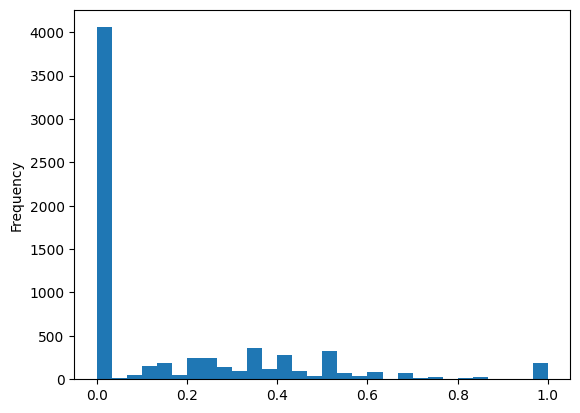

In [186]:
# Dados sem tratamento
features['prop_n_plasmidial_beta-lactam'].plot(kind='hist', bins=30)
plt.show()

In [187]:
features['cat_plasmidial_beta-lactam'] = pd.cut(
    features['prop_n_plasmidial_beta-lactam'],
    bins=[-0.001, 0, 0.5, 1.0001],
    labels=[0,1,2]
).astype("Int64")

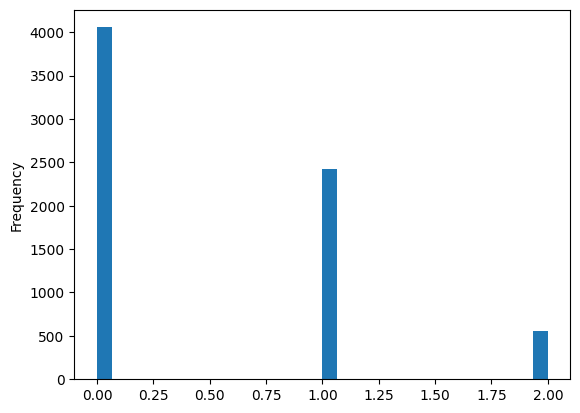

In [188]:
# Dados sem tratamento
features['cat_plasmidial_beta-lactam'].plot(kind='hist', bins=30)
plt.show()

In [189]:
features = features.drop(columns='prop_n_plasmidial_beta-lactam')

features.head()

,pct_genes_cromossomal_efflux,mdr_score_cromossomal,mdr_score_plasmidial,pct_contigs_plasmidial,pct_plasmidial_amr,pct_plasmidial_conjugacao_amr,n_proviruses_por_mb,gc_diff_plasmid_cromossomo,virulence_score_cromossomal,virulence_score_plasmidial,cat_plasmidial_beta-lactam
sample,,,,,,,,,,,
GCA_000216055.2,0.000000,1,0,1.655629,0.000000,0.000000,0.896445,0.18,0,0,0
GCA_000316425.1,2.127660,13,6,5.675676,4.761905,0.000000,1.540586,-2.92,8,4,2
GCA_000223095.2,16.666667,7,0,6.349206,0.000000,0.000000,0.774247,-3.05,6,1,0
GCA_036761135.1,10.000000,10,5,18.269231,10.526316,2.631579,0.252947,0.31,4,0,1
GCA_003670255.1,14.285714,8,5,22.406639,9.259259,1.851852,0.999419,0.90,4,0,1


## Salvando

In [190]:
features.to_csv("../data/processed/features.csv")